# Lab 1.1: Exploration and Exploitation

This lab demonstrates a multi-armed bandit environment and an agent implementing the **epsilon-greedy** exploration-exploitation strategy.

### Objectives
- Construct a Multi-Armed Bandit environment.
- Implement an Epsilon-Greedy Agent that balances exploration and exploitation.
- Implement the incremental value update rule using sample averages.

## 1. Setup & Environment
We define the `MultiArmedBandit` environment class. The reward distribution for each arm has a true mean $q_*(a)$ drawn from a standard normal distribution $\mathcal{N}(0, 1)$, and actual rewards are generated around this mean with unit variance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class MultiArmedBandit:
    def __init__(self, num_arms):
         self.num_arms = num_arms
        # True mean values for each arm (q_*)
        self.true_action_values = np.random.normal(0, 1, num_arms)

    def get_reward(self, action):
        # Reward is sampled from normal distribution with mean true value and variance 1
        return np.random.normal(self.true_action_values[action], 1.0)

## 2. Epsilon-Greedy Agent
The agent implements selection logic and value updates:
- **Action Selection**: Selects a random action with probability $\epsilon$, and selects the greedy action with probability $1 - \epsilon$.
- **Incremental Update**: Updates the value estimate of the selected action:
$$Q(A) \leftarrow Q(A) + \frac{1}{N(A)} [R - Q(A)]$$

In [2]:
class EpsilonGreedyAgent:
    def __init__(self, num_actions, epsilon=0.1):
        self.num_actions = num_actions
        self.epsilon = epsilon
        # Action-value estimates (Q_t)
        self.action_values = np.zeros(num_actions)
        # Count of action selections (N_t)
        self.action_counts = np.zeros(num_actions)

    def select_action(self):
        if np.random.rand() < self.epsilon:
            # Explore: choose a random action
            action = np.random.randint(self.num_actions)
        else:
            # Exploit: choose greedy action (break ties randomly)
            max_val = np.max(self.action_values)
            ties = np.where(self.action_values == max_val)[0]
            action = np.random.choice(ties)
        return action

    def update_value(self, action, reward):
        self.action_counts[action] += 1
        step_size = 1.0 / self.action_counts[action]
        self.action_values[action] += step_size * (reward - self.action_values[action])

## 3. Interaction Loop
We run a simulation of 1000 steps to let the agent interact with the bandit.

In [3]:
# Initialize seed
np.random.seed(0)

num_arms = 10
num_steps = 1000
agent = EpsilonGreedyAgent(num_arms, epsilon=0.1)
bandit = MultiArmedBandit(num_arms)

print("True Mean Values (q_*):")
for i, val in enumerate(bandit.true_action_values):
    print("Arm {}: {:.4f}".format(i, val))

# Interaction Loop
total_rewards = 0
rewards_history = []
for step in range(num_steps):
    action = agent.select_action()
    reward = bandit.get_reward(action)
    agent.update_value(action, reward)
    total_rewards += reward
    rewards_history.append(reward)

print("\nTotal rewards obtained:", total_rewards)
print("Estimated action values (Q):\n", agent.action_values)
print("Action selection counts:\n", agent.action_counts)

True Mean Values (q_*):
Arm 0: 1.7641
Arm 1: 0.4002
Arm 2: 0.9787
Arm 3: 2.2409
Arm 4: 1.8676
Arm 5: -0.9773
Arm 6: 0.9501
Arm 7: -0.1514
Arm 8: -0.1032
Arm 9: 0.4106

Total rewards obtained: 2066.9600928683653
Estimated action values (Q):
 [ 1.3052942   1.00472779  1.08361151  2.22927956  1.96323    -1.0000046
  0.18038788 -0.37521484  0.27073784  0.19168713]
Action selection counts:
 [  8.  17.  14. 888.  27.  11.   6.   8.   7.  14.]


## 4. Visualization
Let's plot the rolling mean of rewards to see how the agent learns and improves performance over time.

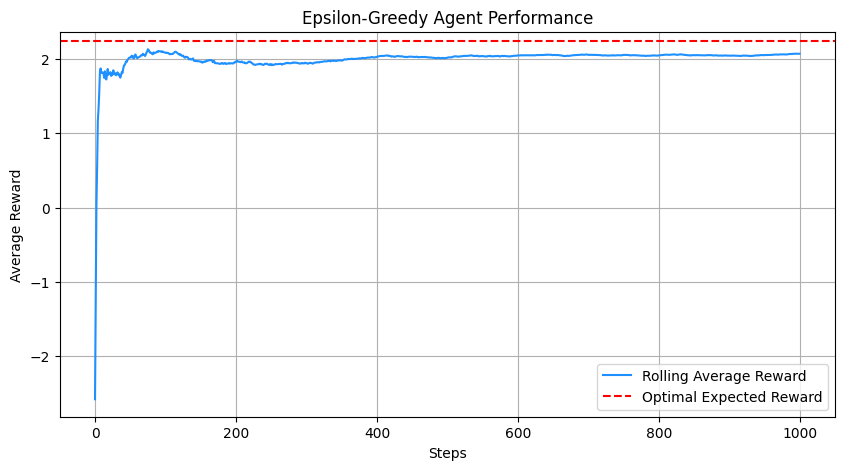

In [4]:
rolling_mean = np.cumsum(rewards_history) / (np.arange(num_steps) + 1)
plt.figure(figsize=(10, 5))
plt.plot(rolling_mean, label='Rolling Average Reward', color='dodgerblue')
plt.axhline(y=np.max(bandit.true_action_values), color='red', linestyle='--', label='Optimal Expected Reward')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Epsilon-Greedy Agent Performance')
plt.legend()
plt.grid(True)
plt.show()